In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [ ]:
import matplotlib.pyplot as plt
import torch
from diffusers import DiffusionPipeline

from textboost.text_encoders import TextBoostModel, TextBoostModelWithProjection

MODEL = "stabilityai/stable-diffusion-xl-base-1.0"
torch.set_grad_enabled(False)
device = torch.device("cpu")

In [6]:
# path = "../output/tb-sdxlbase-n1-testrun6/cat"
path = "../output/tb-sdxlbase-n1-remove_final/backpack/checkpoint-160"

text_encoder = TextBoostModel.from_pretrained(
    MODEL,
    subfolder="text_encoder",
)
text_encoder_2 = TextBoostModelWithProjection.from_pretrained(
    MODEL,
    subfolder="text_encoder_2",
)

pipeline = DiffusionPipeline.from_pretrained(
    MODEL,
    text_encoder=text_encoder,
    text_encoder_2=text_encoder_2,
)

pipeline.text_encoder.load_adapter(os.path.join(path, "text_encoder"))
pipeline.text_encoder.set_lora_mask()
pipeline.text_encoder.replace_lora_forward()

pipeline.text_encoder_2.load_adapter(os.path.join(path, "text_encoder_2"))
pipeline.text_encoder_2.set_lora_mask()
pipeline.text_encoder_2.replace_lora_forward()

# for emb in os.listdir(os.path.join(path, "checkpoint-200")):
#     if (
#         emb in ("scheduler.bin", "optimizer.bin")
#         or emb.endswith(".safetensors")
#         or emb.endswith(".pkl")
#         or os.path.isdir(os.path.join(path, "checkpoint-200", emb))
#     ):
#         continue
#     print(emb)
#     if emb.endswith("_2.bin"):
#         pipeline.load_textual_inversion(
#             os.path.join(path, "checkpoint-200", emb),
#             tokenizer=pipeline.tokenizer_2,
#             text_encoder=pipeline.text_encoder_2,
#         )
#     else:
#         pipeline.load_textual_inversion(
#             os.path.join(path, "checkpoint-200", emb),
#             tokenizer=pipeline.tokenizer,
#             text_encoder=pipeline.text_encoder,
#         )

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 19.26it/s]


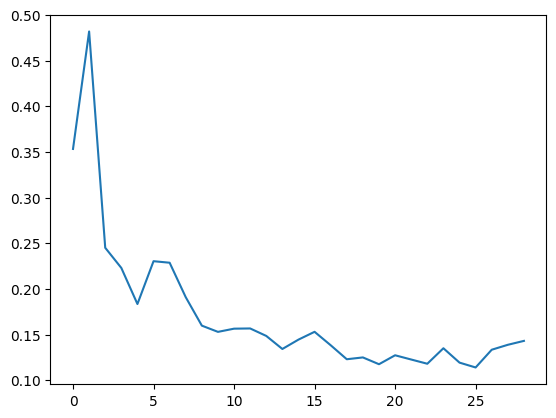

In [7]:
state_dict = pipeline.text_encoder_2.state_dict()

diff = {}
for k, v in state_dict.items():
    if "lora_A" in k:
        l = int(k.split(".")[3])

        w_A = v
        w_B = state_dict[k.replace("lora_A", "lora_B")]
        # print(w_A.shape, w_B.shape)
        w_lora = w_B @ w_A
        w = state_dict[k.replace("lora_A.default", "base_layer")]
        d = torch.norm(w_lora) / torch.norm(w)
        if l not in diff:
            diff[l] = d
        else:
            diff[l] += d

plt.plot(diff.values())

0 tensor(0.5611) tensor(23.4085)
0 tensor(0.6293) tensor(23.9150)
0 tensor(0.5550) tensor(23.7752)
0 tensor(0.7282) tensor(9.3279)
0 tensor(2.0583) tensor(40.8407)
0 tensor(2.0307) tensor(13.4331)
1 tensor(0.7769) tensor(15.6912)
1 tensor(1.4857) tensor(17.2409)
1 tensor(0.5873) tensor(15.7784)
1 tensor(1.0196) tensor(4.6729)
1 tensor(1.1653) tensor(40.6593)
1 tensor(1.1138) tensor(17.9502)
2 tensor(0.4142) tensor(11.1869)
2 tensor(0.4343) tensor(12.1576)
2 tensor(0.3715) tensor(11.0498)
2 tensor(0.4196) tensor(4.4016)
2 tensor(0.8216) tensor(40.8657)
2 tensor(0.8305) tensor(35.6544)
3 tensor(0.4050) tensor(16.1759)
3 tensor(0.4262) tensor(18.1838)
3 tensor(0.4290) tensor(16.5970)
3 tensor(0.4229) tensor(4.0842)
3 tensor(0.8538) tensor(41.7479)
3 tensor(0.8901) tensor(36.0526)
4 tensor(0.3976) tensor(18.3624)
4 tensor(0.4176) tensor(19.2391)
4 tensor(0.4320) tensor(18.5611)
4 tensor(0.4145) tensor(5.4824)
4 tensor(0.8595) tensor(41.6920)
4 tensor(0.8907) tensor(43.0669)
5 tensor(0.4180

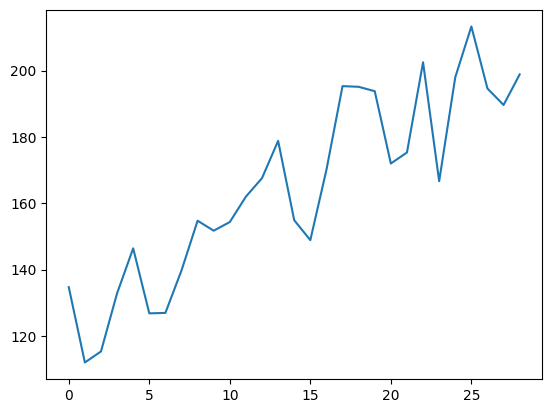

In [13]:
norms = {}

# state_dict = pipeline.text_encoder.state_dict()
state_dict = pipeline.text_encoder_2.state_dict()
for k, v in state_dict.items():
    if "lora_A" in k:
        l = int(k.split(".")[3])

        w_A = v
        w_B = state_dict[k.replace("lora_A", "lora_B")]
        # print(w_A.shape, w_B.shape)
        w_lora = w_B @ w_A
        w = state_dict[k.replace("lora_A.default", "base_layer")]
        print(l, w_lora.norm(), w.norm())
        if l not in norms:
            norms[l] = w.norm()
        else:
            norms[l] += w.norm()
plt.plot(norms.values())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


norm = np.asarray(
    [
        0.1273,
        1.2755,
        1.4443,
        1.5153,
        1.6922,
        1.8137,
        2.2858,
        2.2313,
        2.6651,
        2.8570,
        3.0166,
        3.0610,
        3.0239,
        3.0210,
        3.0135,
        2.9839,
        2.9019,
        2.8820,
        2.8208,
        2.8015,
        2.8286,
        2.8382,
        2.8608,
        2.8470,
        2.8885,
        2.8889,
        2.8488,
        2.8497,
        3.0847,
        3.3079,
        3.5861,
        3.8987,
        4.8744,
    ]
)

relative_norm = norm[1:] / norm[:-1]

plt.plot(relative_norm)
plt.xlabel("Layer")
plt.ylabel("Magnitude of Embedding")
plt.title("Magnitude of Embedding in Text Encoder")